In [34]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from packaging import version
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


Load the red wine dataset


In [35]:
# Load the red wine dataset

red_wine_data = pd.read_csv("../data/winequality-red.csv", delimiter=";")


Explore the Dataset

In [36]:
# Display the first few rows to see the features
red_wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [37]:
#Explore the dataset
red_wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [38]:
# Display Descriptive Statistics
red_wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Data Visualization

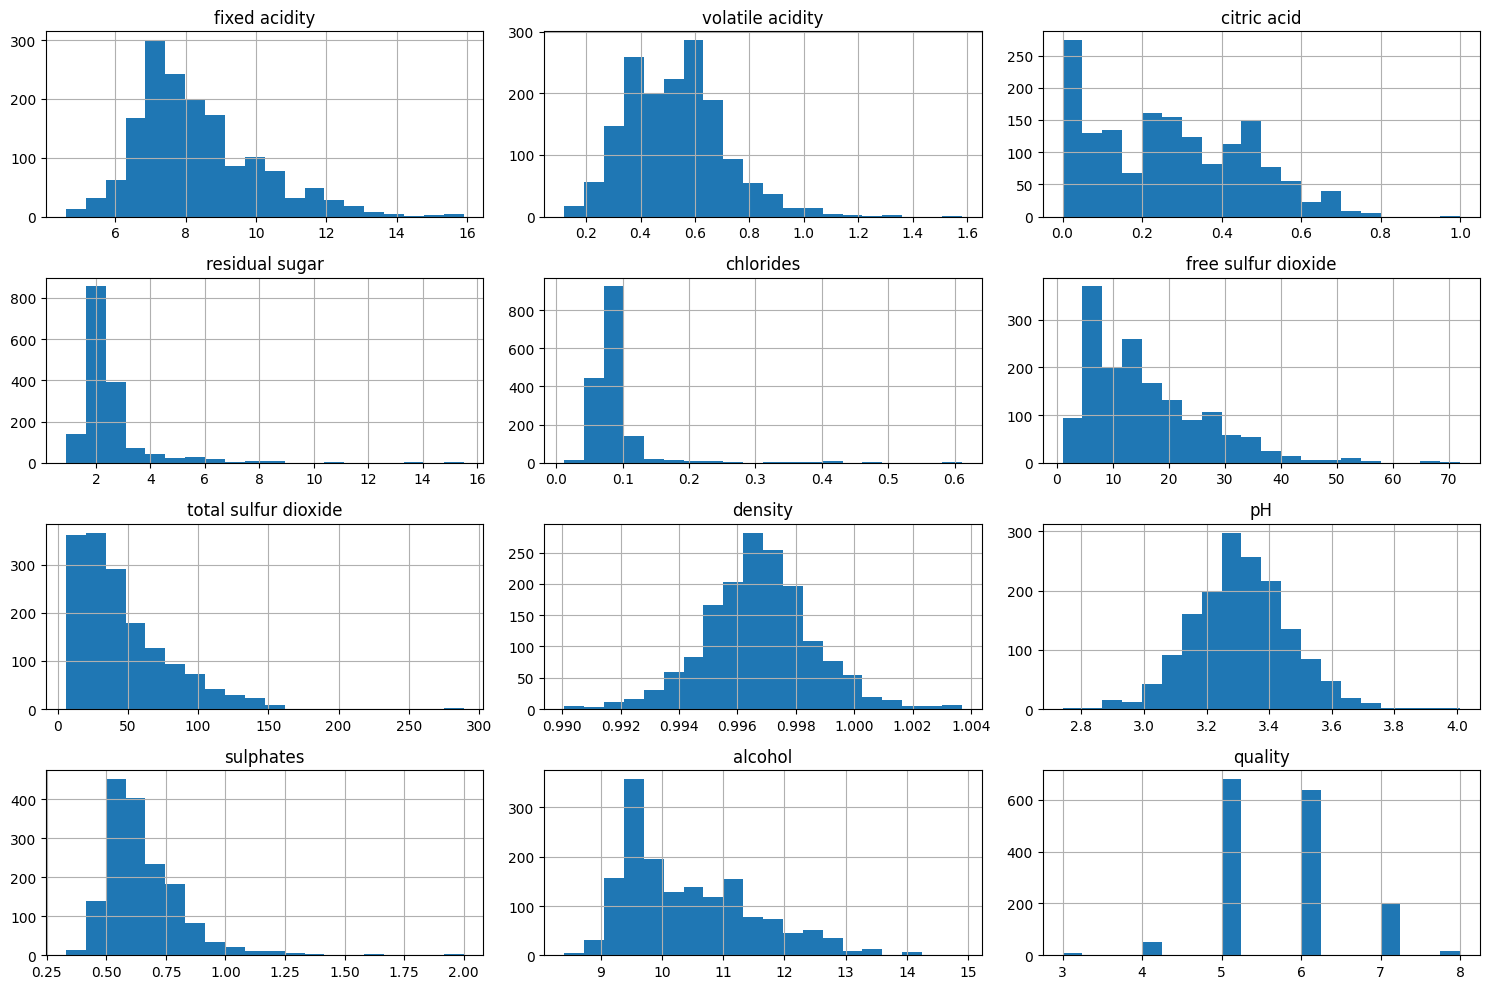

In [39]:
# Data Visualization
red_wine_data.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()


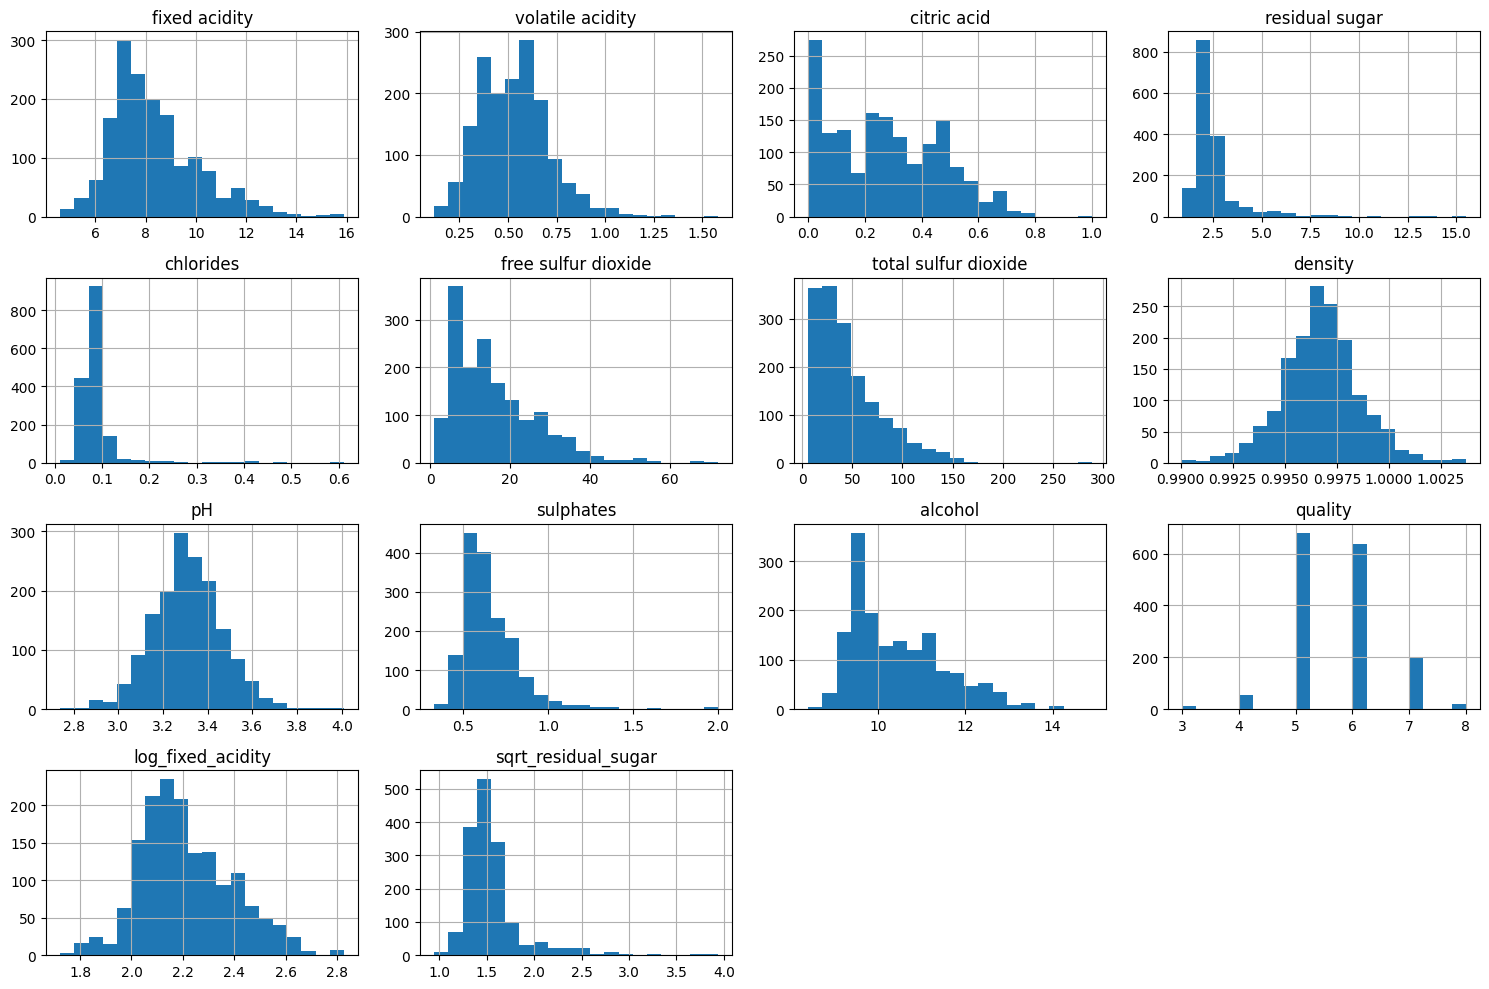

In [40]:
#log transformation to make it look more gausian for the fixed acidity
red_wine_data['log_fixed_acidity'] = np.log1p(red_wine_data['fixed acidity'])
#square root tranforamtion to make it look more gausian for the residual sugar
red_wine_data['sqrt_residual_sugar'] = np.sqrt(red_wine_data['residual sugar'])

# re-plot the histogram to compare
red_wine_data.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

Correlation Analysis

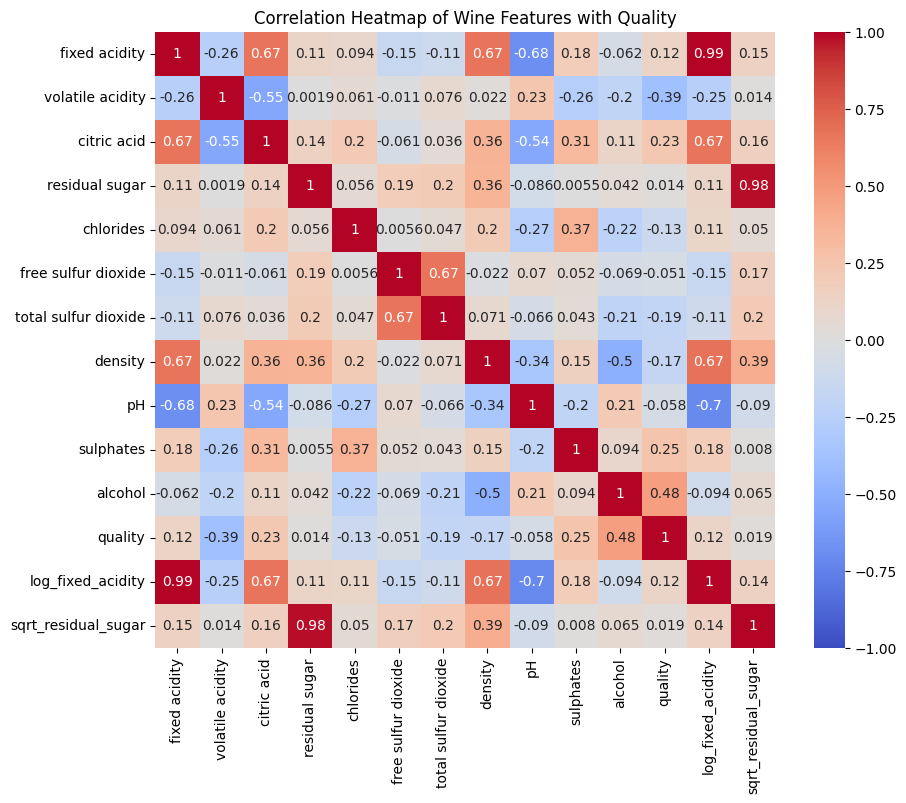

Correlation of each feature with wine quality:
 quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
log_fixed_acidity       0.115684
sqrt_residual_sugar     0.019048
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [41]:
# Calculate correlation matrix
correlation_matrix = red_wine_data.corr()

# Plot the correlation heatmap for all features
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Wine Features with Quality")
plt.show()

# Show correlations of each feature with quality only
quality_correlations = correlation_matrix['quality'].sort_values(ascending=False)
print("Correlation of each feature with wine quality:\n", quality_correlations)

Split the dataset into a training and a testing set retaining 80% and 20% of the total number of samples,
respectively, using random shuffling and splitting that retains the statistical properties of the input data
(stratified) with respect to quality

In [42]:
# Define the features (X) and target (y)
X = red_wine_data.drop(columns=['quality'])
y = red_wine_data['quality']

# Split the dataset using stratification on the 'quality' feature
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Verify the split
print("Training set quality distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting set quality distribution:\n", y_test.value_counts(normalize=True))


Training set quality distribution:
 quality
5    0.426114
6    0.398749
7    0.124316
4    0.032838
8    0.011728
3    0.006255
Name: proportion, dtype: float64

Testing set quality distribution:
 quality
5    0.425000
6    0.400000
7    0.125000
4    0.034375
8    0.009375
3    0.006250
Name: proportion, dtype: float64


Scale the data with a Standard scaler and train a linear regression model. Evaluate the performance
of the model, using the test set, with respect to metrics such as R2-score, Mean Absolute Error, Mean
Absolute Percentage Error, Mean Squared Error and Accuracy.

In [43]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mape = (abs((y_test - y_pred) / y_test).mean()) * 100  # Mean Absolute Percentage Error

# Print the results
print(f"R² Score: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Mean Squared Error (MSE): {mse:.2f}")


R² Score: 0.35
Mean Absolute Error (MAE): 0.50
Mean Absolute Percentage Error (MAPE): 9.17%
Mean Squared Error (MSE): 0.42


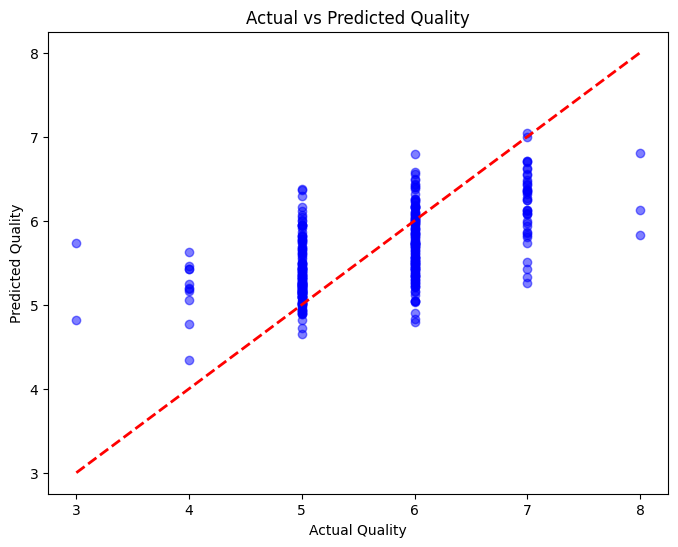

In [44]:
# Plot Actuals vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="b")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Quality")
plt.show()

Perform 10-fold cross validation and compute the mean and standard deviation of the scores over the
folds. Is the model’s R2-score within the limits defined by the 10-fold cross validation?

In [45]:
# Perform 10-fold cross-validation on the scaled training data
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=10, scoring='r2')

# Calculate mean and standard deviation of the cross-validation scores
cv_mean = np.mean(cv_scores)
cv_std = np.std(cv_scores)

# Print cross-validation results
print(f"10-Fold Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R² Score: {cv_mean:.2f}")
print(f"Standard Deviation of R² Scores: {cv_std:.2f}")

# Check if the test R² score is within the mean ± std deviation range
test_r2_within_cv_range = (r2 >= cv_mean - cv_std) and (r2 <= cv_mean + cv_std)

print(f"Test R² Score: {r2:.2f}")
print(f"Is Test R² Score within Mean ± Std of CV R² Scores? {'Yes' if test_r2_within_cv_range else 'No'}")


10-Fold Cross-Validation R² Scores: [0.22924844 0.34918282 0.40553235 0.40036035 0.29301947 0.3836894
 0.45824031 0.31302085 0.37950905 0.22475812]
Mean R² Score: 0.34
Standard Deviation of R² Scores: 0.07
Test R² Score: 0.35
Is Test R² Score within Mean ± Std of CV R² Scores? Yes


# Conclusions

The exploratory analysis revealed several relationships between physicochemical properties and wine quality.

Key findings include:

- Alcohol content tends to increase with wine quality.
- Volatile acidity is negatively correlated with quality.
- Citric acid shows a mild positive correlation.
- Most variables are approximately normally distributed, while a few exhibit skewness and outliers.

R² score = 0,35 The model explains about 35% of the differencies in wine quality using the given features
RMSE = 65% of the chemical relations remains unexplained
MAE = 0.50 on average the predictions are wrong about 0.5 quality points
MAPE = 9.17% Predictions are approximately 9% away from the real quality values on average

After the 10 Cross Validation R² score 0.34
Standard Deviation: 0.07 
Lower bound:
0.34 - 0.07 = 0.27
Upper bound:
0.34 + 0.07 = 0.41 --> R² between 0.27 and 0.41 The test R² is within the expected CV range

The model achieved an average 10-fold cross-validation R² score of 0.34 (±0.07), indicating consistent predictive performance across different subsets of the dataset. The final test R² score of 0.35 falls within the expected cross-validation range, suggesting that the model generalizes well and does not suffer from significant overfitting
